In [2]:
!pip install evaluate

In [16]:
!pip uninstall torch transformers -y
!pip install torch transformers


Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0
Found existing installation: transformers 4.52.0.dev0
Uninstalling transformers-4.52.0.dev0:
  Successfully uninstalled transformers-4.52.0.dev0
  Using cached torch-2.6.0-cp310-cp310-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached transformers-4.51.3-py3-none-any.whl.metadata (38 kB)
Using cached torch-2.6.0-cp310-cp310-manylinux1_x86_64.whl (766.7 MB)
Using cached transformers-4.51.3-py3-none-any.whl (10.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.1.0+cu121 requires torch==2.1.0, but you have torch 2.6.0 which is incompatible.
torchvision 0.16.0+cu121 requires torch==2.1.0, but you have torch 2.6.0 which is incompatible.


In [3]:
pip install numpy==1.24.4


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from datasets import load_dataset
import os
import evaluate


MODEL_ID = "microsoft/Phi-3-mini-4k-instruct" 


model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,  
    device_map="auto",
    trust_remote_code=True
)


tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" 


dataset = load_dataset("gsm8k", "main")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def format_instruction(example):
    """Format GSM8K examples for instruction tuning"""
    prompt = f"user\nSolve the following math problem step by step:\n{example['question']}\n\nassistant\n"
    
 
    answer = example['answer']
    if "####" in answer:
        answer = answer.replace("####", "Therefore, the answer is")
    

    full_text = prompt + answer + tokenizer.eos_token
    

    tokenized = tokenizer(
        full_text, 
        truncation=True, 
        padding="max_length", 
        max_length=2048
    )

    tokenized["labels"] = tokenized["input_ids"].copy()
    
    return tokenized


tokenized_train = dataset["train"].map(
    format_instruction,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing train dataset"
)

tokenized_test = dataset["test"].map(
    format_instruction,
    remove_columns=dataset["test"].column_names,
    desc="Tokenizing test dataset"
)


tokenized_train = tokenized_train.select(range(500))
tokenized_test = tokenized_test.select(range(100))


Tokenizing train dataset:   0%|          | 0/7473 [00:00<?, ? examples/s]

In [ ]:

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
    pad_to_multiple_of=8 
)

training_args = TrainingArguments(
    output_dir="./phi3-gsm8k-full-finetune",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    fp16=False,
    bf16=True,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_dir="./logs",
    logging_steps=3,
    eval_strategy="epoch",  
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=4,
    ddp_find_unused_parameters=False,
    group_by_length=True,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    tokenizer=tokenizer,
)

/tmp/ipykernel_1076/1386426323.py:38: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [27]:
# Start training
trainer.train()

# Save the fine-tuned model
trainer.save_model("./phi3-gsm8k-full-finetune-final")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch,Training Loss,Validation Loss
1,0.268800,1.082324
2,0.262500,1.103602


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Found existing installation: transformers 4.52.0.dev0
Uninstalling transformers-4.52.0.dev0:
  Successfully uninstalled transformers-4.52.0.dev0


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Cloning https://github.com/huggingface/transformers to /tmp/pip-req-build-08wafe29
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers /tmp/pip-req-build-08wafe29
  Resolved https://github.com/huggingface/transformers to commit 4cc6b6065426bdc66cac47bab1ffb26d3807fc53
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-4.52.0.dev0-py3-none-any.whl size=11299668 sha256=5c8d56a1e828e167a502354e02866d27230a19c3d95444d1a170944e32689b18
  Stored in directory: /tmp/pip-ephem-wheel-cache-l5152top/wheels/c0/14/d6/6c9a5582d2ac191ec0a483be151a4495fe1eb2a6706ca49f1b
Successfully built transformers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating perplexity for training set examples...


100%|████████████████████████████████████████████████████████████████████████████████| 7473/7473 [05:46<00:00, 21.55it/s]


Training Set Perplexity Statistics:
Mean: 1.32
Median: 1.29
Min: 1.06
Max: 2.60
Results saved to gsm8k_train_perplexity_results.json
Histogram saved to gsm8k_train_perplexity_histogram.png


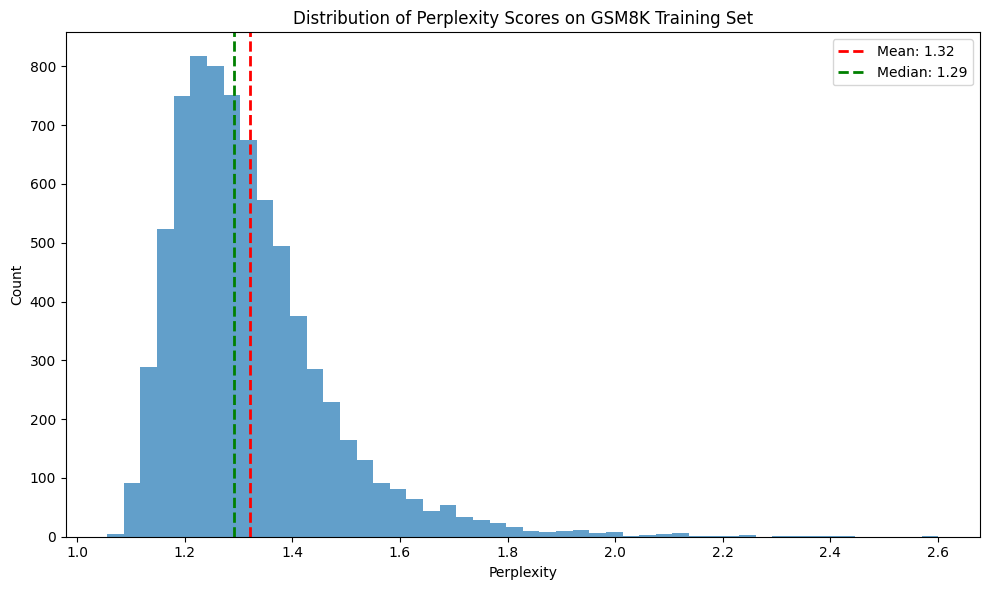

In [ ]:

!pip uninstall -y transformers

!pip install git+https://github.com/huggingface/transformers


import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
import json
import matplotlib.pyplot as plt


MODEL_PATH = "./phi3-gsm8k-full-finetune-final" 
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token


dataset = load_dataset("gsm8k", "main")
train_dataset = dataset["train"]


def calculate_perplexity(text, model, tokenizer, max_length=2048):
    """Calculate perplexity for a single text example"""
    encodings = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
    input_ids = encodings.input_ids.to(model.device)
    
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        neg_log_likelihood = outputs.loss.item()
        
 
    perplexity = np.exp(neg_log_likelihood)
    return perplexity


def format_example(example):
    """Format GSM8K example for perplexity calculation"""
    prompt = f"user\nSolve the following math problem step by step:\n{example['question']}\n\nassistant\n"
    
 
    answer = example['answer']
    if "####" in answer:
        answer = answer.replace("####", "Therefore, the answer is")
    
   
    full_text = prompt + answer
    
    return full_text


results = []
print("Calculating perplexity for training set examples...")
for example in tqdm(train_dataset):
    try:
        formatted_text = format_example(example)
        perplexity = calculate_perplexity(formatted_text, model, tokenizer)
        
       
        results.append({
            "question": example["question"],
            "perplexity": perplexity
        })
    except Exception as e:
        print(f"Error processing example: {e}")
        continue


perplexities = [result["perplexity"] for result in results]
mean_perplexity = np.mean(perplexities)
median_perplexity = np.median(perplexities)
min_perplexity = np.min(perplexities)
max_perplexity = np.max(perplexities)

print(f"Training Set Perplexity Statistics:")
print(f"Mean: {mean_perplexity:.2f}")
print(f"Median: {median_perplexity:.2f}")
print(f"Min: {min_perplexity:.2f}")
print(f"Max: {max_perplexity:.2f}")

# Save the results to a JSON file
output_data = {
    "individual_results": results,
    "statistics": {
        "mean_perplexity": mean_perplexity,
        "median_perplexity": median_perplexity,
        "min_perplexity": min_perplexity,
        "max_perplexity": max_perplexity
    }
}

with open("gsm8k_train_perplexity_results.json", "w") as f:
    json.dump(output_data, f, indent=2)

print("Results saved to gsm8k_train_perplexity_results.json")

# Create and save a histogram of perplexities
plt.figure(figsize=(10, 6))
plt.hist(perplexities, bins=50, alpha=0.7)
plt.axvline(mean_perplexity, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_perplexity:.2f}')
plt.axvline(median_perplexity, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_perplexity:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Count')
plt.title('Distribution of Perplexity Scores on GSM8K Training Set')
plt.legend()
plt.tight_layout()
plt.savefig('gsm8k_train_perplexity_histogram.png')
print("Histogram saved to gsm8k_train_perplexity_histogram.png")


In [ ]:

perplexities = []  

print("Calculating perplexity for training set examples...")
for example in tqdm(train_dataset):
    try:
        formatted_text = format_example(example)
        perplexity = calculate_perplexity(formatted_text, model, tokenizer)
        perplexities.append(perplexity) 
    except Exception as e:
        print(f"Error processing example: {e}")
        continue

perplexity_vector = np.array(perplexities)
np.save('perplexity_vector.npy', perplexity_vector)
print(f"Perplexity vector saved to perplexity_vector.npy")


Calculating perplexity for training set examples...


100%|████████████████████████████████████████████████████████████████████████████████| 7473/7473 [05:57<00:00, 20.89it/s]

Perplexity vector saved to perplexity_vector.npy


In [1]:
pip install cvxpy


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import sys
import datetime


try:
    import cvxpy as cp
except ImportError:
    print("\n=== ERROR: cvxpy package not found ===")
    print("Please install it using: pip install cvxpy")
    print("Then run the script again.\n")
    sys.exit(1)

class ProgressTracker:
    """Track overall progress across multiple steps"""
    def __init__(self, total_steps):
        self.total_steps = total_steps
        self.current_step = 0
        self.start_time = time.time()
        self.step_times = []
        
    def update(self, step_name):
        self.current_step += 1
        elapsed = time.time() - self.start_time
        self.step_times.append(elapsed)
        
       
        if len(self.step_times) > 1:
            avg_time_per_step = elapsed / self.current_step
            remaining_steps = self.total_steps - self.current_step
            eta = avg_time_per_step * remaining_steps
            eta_str = str(datetime.timedelta(seconds=int(eta)))
        else:
            eta_str = "calculating..."
            
     
        print(f"\n[{self.current_step}/{self.total_steps}] {step_name} - "
              f"Elapsed: {str(datetime.timedelta(seconds=int(elapsed)))}, "
              f"ETA: {eta_str}")
        
     
        progress = int(30 * self.current_step / self.total_steps)
        bar = "█" * progress + "░" * (30 - progress)
        percent = 100 * self.current_step / self.total_steps
        print(f"Overall Progress: |{bar}| {percent:.1f}%")
        
    def complete(self):
        total_time = time.time() - self.start_time
        print(f"\n✅ All tasks completed in {str(datetime.timedelta(seconds=int(total_time)))}")

def load_data(utility_path, diversity_path, progress):
    """Load utility vector and diversity matrix from .npy files"""
    progress.update("Loading data files")
    
    try:
        print(f"Loading utility vector from {utility_path}...")
        start_time = time.time()
        u = np.load(utility_path)
        print(f"Loaded in {time.time() - start_time:.2f} seconds")
        
        print(f"Loading diversity matrix from {diversity_path}...")
        start_time = time.time()
        D = np.load(diversity_path)
        print(f"Loaded in {time.time() - start_time:.2f} seconds")
        
    
        print("Processing loaded data...")
        start_time = time.time()
        u = np.maximum(u, 0)
        D = np.maximum(D, 0)
        print(f"Processing completed in {time.time() - start_time:.2f} seconds")
        
        print(f"✓ Loaded utility vector of shape {u.shape}")
        print(f"✓ Loaded diversity matrix of shape {D.shape}")
        
        return u, D
    except FileNotFoundError as e:
        print(f"❌ Error loading data: {e}")
        raise

def construct_Q_matrix(u, D, lambda_param, progress):
    """Construct the Q matrix as described in the paper"""
    progress.update("Constructing Q matrix")
    
    print(f"Building Q matrix with lambda = {lambda_param}...")
    start_time = time.time()
    N = len(u)
    Q = np.zeros((N, N))
    

    Q = lambda_param * D
    
  
    np.fill_diagonal(Q, u)
    
    print(f"✓ Q matrix construction completed in {time.time() - start_time:.2f} seconds")
    return Q

def solve_lp_relaxation(Q, k, progress):
    """Solve the LP relaxation as described in Equation (11)"""
    progress.update("Solving LP relaxation")
    
    N = Q.shape[0]
    print(f"Setting up LP relaxation for {N} variables...")
    
   
    start_time = time.time()
    x = cp.Variable(N)
    W = cp.Variable((N, N))
    print(f"Variables defined in {time.time() - start_time:.2f} seconds")
    

    print("Setting up objective function...")
    start_time = time.time()
    objective = cp.Maximize(cp.sum(cp.multiply(Q, W)))
    print(f"Objective defined in {time.time() - start_time:.2f} seconds")
    
 
    print("Setting up constraints (this may take a while for large matrices)...")
    start_time = time.time()
    constraints = []
    
   
    for i in tqdm(range(N), desc="Creating constraints"):
        for j in range(N):
            constraints.append(-x[i] - x[j] + 2 * W[i, j] <= 0)
    
  
    constraints.append(0 <= x)
    constraints.append(x <= 1)
    constraints.append(0 <= W)
    constraints.append(W <= 1)
    
  
    constraints.append(cp.sum(x) == k)
    print(f"Constraints defined in {time.time() - start_time:.2f} seconds")
    
  
    print(f"Solving LP relaxation with {len(constraints)} constraints...")
    start_time = time.time()
    prob = cp.Problem(objective, constraints)
    try:
        print("Optimization in progress (this may take several minutes for large problems)...")
        prob.solve(solver=cp.ECOS, verbose=True)
        solve_time = time.time() - start_time
        
        
        x_sol = x.value
        W_sol = W.value
        
        print(f"✓ LP relaxation completed in {solve_time:.2f} seconds")
        print(f"✓ LP relaxation status: {prob.status}")
        print(f"✓ LP relaxation objective value: {prob.value:.6f}")
        
        return x_sol, W_sol
    except Exception as e:
        print(f"❌ Error solving LP relaxation: {e}")
        print("Falling back to a random solution...")
        
       
        x_random = np.zeros(N)
        indices = np.random.choice(N, size=k, replace=False)
        x_random[indices] = 1
        return x_random, None

def round_solution(x_sol, k, progress):
    """Round the relaxed solution to a binary vector"""
    progress.update("Rounding solution")
    
    print("Rounding continuous solution to binary...")
    start_time = time.time()
    
 
    largest_indices = np.argsort(x_sol)[-k:]
    
  
    x_binary = np.zeros_like(x_sol)
    x_binary[largest_indices] = 1
    
    print(f"✓ Rounding completed in {time.time() - start_time:.2f} seconds")
    return x_binary

def evaluate_objective(x, Q):
    """Evaluate the objective function x^T Q x"""
    return x.T @ Q @ x

def iterative_truncated_power_algorithm(Q, k, x_init, progress, max_iter=100, tol=1e-6):
    """Implement the Iterative Truncated Power Algorithm"""
    progress.update("Running Iterative Truncated Power Algorithm")
    
    N = Q.shape[0]
    
   
    print("Checking if Q is positive semi-definite...")
    start_time = time.time()
    min_eig = np.min(np.linalg.eigvalsh(Q))
    if min_eig < 0:
        print(f"⚠️ Q is not PSD, minimum eigenvalue: {min_eig:.6f}")
        print("Shifting Q to make it PSD...")
        Q_psd = Q - 1.1 * min_eig * np.eye(N)
        print("Q shifted to ensure PSD property")
    else:
        Q_psd = Q
        print("✓ Q is already positive semi-definite")
    print(f"PSD check completed in {time.time() - start_time:.2f} seconds")
    
   
    x_current = x_init.copy()
    obj_values = [evaluate_objective(x_current, Q)]
    
    print(f"Starting ITPA with initial objective value: {obj_values[0]:.6f}")
    print(f"Will run up to {max_iter} iterations or until convergence")
    start_time = time.time()
    last_update_time = start_time
    
    # ITPA iterations
    pbar = tqdm(range(max_iter), desc="ITPA Progress")
    for t in pbar:
      
        x_prime = Q_psd @ x_current
        
     
        largest_indices = np.argsort(x_prime)[-k:]
        x_next = np.zeros_like(x_current)
        x_next[largest_indices] = 1
        
    
        obj_value = evaluate_objective(x_next, Q)
        obj_values.append(obj_value)
        
        pbar.set_postfix({
            'Objective': f'{obj_value:.6f}', 
            'Elapsed': f'{time.time() - start_time:.1f}s'
        })
        
       
        current_time = time.time()
        if current_time - last_update_time > 10:  
            iteration_rate = (t + 1) / (current_time - start_time)
            remaining_iterations = max_iter - (t + 1)
            eta = remaining_iterations / iteration_rate if iteration_rate > 0 else 0
            
            print(f"\nIteration {t+1}/{max_iter} ({(t+1)/max_iter*100:.1f}%)")
            print(f"Current objective: {obj_value:.6f}")
            print(f"Rate: {iteration_rate:.2f} iterations/sec")
            print(f"Estimated time remaining: {str(datetime.timedelta(seconds=int(eta)))}")
            
            last_update_time = current_time
        
        # Check convergence
        if np.array_equal(x_next, x_current):
            print(f"\n✅ ITPA converged after {t+1} iterations!")
            break
            
        # Update current solution
        x_current = x_next
    
    total_time = time.time() - start_time
    print(f"\n✓ ITPA completed in {total_time:.2f} seconds")
    print(f"✓ Average time per iteration: {total_time/(t+1):.4f} seconds")
    
    return x_current, obj_values

def plot_convergence(obj_values, progress):
    """Plot the convergence of the objective function"""
    progress.update("Plotting convergence")
    
    print("Generating convergence plot...")
    plt.figure(figsize=(10, 5))
    plt.plot(obj_values)
    plt.xlabel('Iteration')
    plt.ylabel('Objective Value')
    plt.title('ITPA Convergence')
    plt.grid(True)
    
    print("Saving plot to itpa_convergence.png...")
    plt.savefig('itpa_convergence.png')
    print("✓ Convergence plot saved")
    
def plot_selected_samples(x_binary, N, progress):
    """Visualize the selected samples"""
    progress.update("Visualizing selected samples")
    
    print("Generating selected samples visualization...")
    plt.figure(figsize=(12, 2))
    plt.scatter(range(N), np.ones(N), marker='o', c='lightgray', s=50)
    selected = np.where(x_binary == 1)[0]
    plt.scatter(selected, np.ones(len(selected)), marker='o', c='red', s=80)
    plt.yticks([])
    plt.xlabel('Sample Index')
    plt.title('Selected Samples (in red)')
    
    print("Saving visualization to selected_samples.png...")
    plt.savefig('selected_samples.png')
    print("✓ Sample visualization saved")

def main():
  
    total_steps = 7
    progress = ProgressTracker(total_steps)
    
    # Parameters
    utility_path = 'perplexity_vector.npy'
    diversity_path = 'gsm8k_diversity_scores.npy'
    k = 900 
    lambda_param = 0.5  
    
    print("\n==== SUBSET SELECTION USING ITERATIVE TRUNCATED POWER ALGORITHM ====")
    print(f"Target: Select {k} samples from the dataset")
    print(f"Lambda parameter: {lambda_param}")
    print(f"Utility file: {utility_path}")
    print(f"Diversity file: {diversity_path}")
    print("="*70)
    
    # Load data
    start_time = time.time()
    try:
        u, D = load_data(utility_path, diversity_path, progress)
    except FileNotFoundError:
        print("\n⚠️ Files not found. Using random data for demonstration.")
      
        N = 100
        print(f"Generating random data with N = {N}...")
        u = np.random.rand(N)
        D = np.random.rand(N, N)
       
        D = (D + D.T) / 2
        np.fill_diagonal(D, 0) 
        print("✓ Random data generated")
    

    N = len(u)
    print(f"\nProblem size: N = {N} samples")
    print(f"Memory usage estimate: ~{(N*N*8)/(1024*1024):.2f} MB for diversity matrix")
    

    Q = construct_Q_matrix(u, D, lambda_param, progress)
    
 
    x_sol, W_sol = solve_lp_relaxation(Q, k, progress)
    x_init = round_solution(x_sol, k, progress)
    
 
    init_obj = evaluate_objective(x_init, Q)
    print(f"\nInitial objective value after rounding: {init_obj:.6f}")
    
 
    x_final, obj_values = iterative_truncated_power_algorithm(Q, k, x_init, progress)
    

    final_obj = evaluate_objective(x_final, Q)
    print(f"\nFinal objective value: {final_obj:.6f}")
    print(f"Improvement: {(final_obj - init_obj) / init_obj * 100:.2f}%")
    
 
    plot_convergence(obj_values, progress)
    
   
    plot_selected_samples(x_final, N, progress)
    
   
    selected_indices = np.where(x_final == 1)[0]
    
  
    progress.update("Saving results")
    print("\nSelected sample indices:")
    print(selected_indices)
    
    print("\nSaving results to files...")
    np.save('selected_samples.npy', selected_indices)
    np.save('final_x_vector.npy', x_final)
    print("✓ Results saved")
    
   
    progress.complete()
    
    print("\n==== SUMMARY ====")
    print(f"Total samples: {N}")
    print(f"Selected samples: {k}")
    print(f"Final objective value: {final_obj:.6f}")
    print(f"Total time elapsed: {time.time() - start_time:.2f} seconds")
    print("================")
    
    return x_final, selected_indices

if __name__ == "__main__":
    try:
        x_final, selected_indices = main()
        print("\n✅ Program completed successfully!")
    except Exception as e:
        print(f"\n❌ An error occurred: {e}")
        import traceback
        traceback.print_exc()



==== SUBSET SELECTION USING ITERATIVE TRUNCATED POWER ALGORITHM ====
Target: Select 900 samples from the dataset
Lambda parameter: 0.5
Utility file: perplexity_vector.npy
Diversity file: gsm8k_diversity_scores.npy

[1/7] Loading data files - Elapsed: 0:00:00, ETA: calculating...
Overall Progress: |████░░░░░░░░░░░░░░░░░░░░░░░░░░| 14.3%
Loading utility vector from perplexity_vector.npy...
Loaded in 0.00 seconds
Loading diversity matrix from gsm8k_diversity_scores.npy...
Loaded in 0.22 seconds
Processing loaded data...
Processing completed in 0.15 seconds
✓ Loaded utility vector of shape (7473,)
✓ Loaded diversity matrix of shape (7473, 7473)

Problem size: N = 7473 samples
Memory usage estimate: ~426.07 MB for diversity matrix

[2/7] Constructing Q matrix - Elapsed: 0:00:00, ETA: 0:00:00
Overall Progress: |████████░░░░░░░░░░░░░░░░░░░░░░| 28.6%
Building Q matrix with lambda = 0.5...
✓ Q matrix construction completed in 0.10 seconds

[3/7] Solving LP relaxation - Elapsed: 0:00:00, ETA: 0:

Creating constraints: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 7473/7473 [3:43:38<00:00,  1.80s/it]


Constraints defined in 13418.97 seconds
Solving LP relaxation with 55845734 constraints...
Optimization in progress (this may take several minutes for large problems)...
                                     CVXPY                                     
                                     v1.6.5                                    



==== SUBSET SELECTION USING ITERATIVE TRUNCATED POWER ALGORITHM ====
Target: Select 1900 samples from the dataset
Lambda parameter: 0.5
Utility file: perplexity_vector.npy
Diversity file: gsm8k_diversity_scores.npy

[1/5] Loading data files - Elapsed: 0:00:00, ETA: calculating...
Overall Progress: |██████░░░░░░░░░░░░░░░░░░░░░░░░| 20.0%
Loading utility vector from perplexity_vector.npy...
Loaded in 0.00 seconds
Loading diversity matrix from gsm8k_diversity_scores.npy...
Loaded in 0.13 seconds
Processing loaded data...
Processing completed in 0.12 seconds
✓ Loaded utility vector of shape (7473,)
✓ Loaded diversity matrix of shape (7473, 7473)

Problem size: N = 7473 samples
Memory usage estimate: ~426.07 MB for diversity matrix

[2/5] Constructing Q matrix - Elapsed: 0:00:00, ETA: 0:00:00
Overall Progress: |████████████░░░░░░░░░░░░░░░░░░| 40.0%
Building Q matrix with lambda = 0.5...
✓ Q matrix construction completed in 0.09 seconds

[3/5] Creating initial solution - Elapsed: 0:00:00, ET

ITPA Progress:   1%|▋                                                                | 1/100 [00:00<00:52,  1.88it/s, Objective=1151513.959713, Elapsed=0.5s]



✅ ITPA converged after 2 iterations!

✓ ITPA completed in 0.54 seconds
✓ Average time per iteration: 0.2678 seconds

Final objective value: 1151513.959713
Improvement: 3.67%

[5/5] Plotting convergence - Elapsed: 0:00:12, ETA: 0:00:00
Overall Progress: |██████████████████████████████| 100.0%
Generating convergence plot...
Saving plot to itpa_convergence.png...
✓ Convergence plot saved

[6/5] Visualizing selected samples - Elapsed: 0:00:12, ETA: -1 day, 23:59:58
Overall Progress: |████████████████████████████████████| 120.0%
Generating selected samples visualization...
Saving visualization to selected_samples.png...
✓ Sample visualization saved

[7/5] Saving results - Elapsed: 0:00:12, ETA: -1 day, 23:59:57
Overall Progress: |██████████████████████████████████████████| 140.0%

Selected sample indices:
[   9   17   27 ... 7463 7470 7472]

Saving results to files...
✓ Results saved

✅ All tasks completed in 0:00:12

==== SUMMARY ====
Total samples: 7473
Selected samples: 1900
Final objec

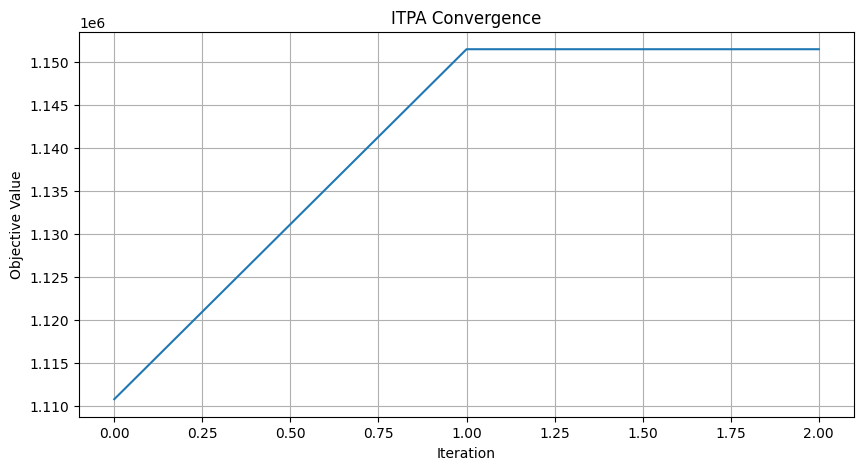

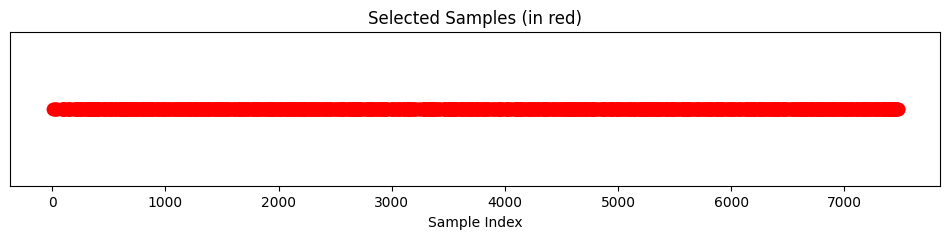

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import sys
import datetime


try:
    import cvxpy as cp
except ImportError:
    print("\n=== ERROR: cvxpy package not found ===")
    print("Please install it using: pip install cvxpy")
    print("Then run the script again.\n")
    sys.exit(1)

class ProgressTracker:
    """Track overall progress across multiple steps"""
    def __init__(self, total_steps):
        self.total_steps = total_steps
        self.current_step = 0
        self.start_time = time.time()
        self.step_times = []
        
    def update(self, step_name):
        self.current_step += 1
        elapsed = time.time() - self.start_time
        self.step_times.append(elapsed)
        
      
        if len(self.step_times) > 1:
            avg_time_per_step = elapsed / self.current_step
            remaining_steps = self.total_steps - self.current_step
            eta = avg_time_per_step * remaining_steps
            eta_str = str(datetime.timedelta(seconds=int(eta)))
        else:
            eta_str = "calculating..."
            
        # Print progress
        print(f"\n[{self.current_step}/{self.total_steps}] {step_name} - "
              f"Elapsed: {str(datetime.timedelta(seconds=int(elapsed)))}, "
              f"ETA: {eta_str}")
        
        # Print progress bar
        progress = int(30 * self.current_step / self.total_steps)
        bar = "█" * progress + "░" * (30 - progress)
        percent = 100 * self.current_step / self.total_steps
        print(f"Overall Progress: |{bar}| {percent:.1f}%")
        
    def complete(self):
        total_time = time.time() - self.start_time
        print(f"\n✅ All tasks completed in {str(datetime.timedelta(seconds=int(total_time)))}")

def load_data(utility_path, diversity_path, progress):
    """Load utility vector and diversity matrix from .npy files"""
    progress.update("Loading data files")
    
    try:
        print(f"Loading utility vector from {utility_path}...")
        start_time = time.time()
        u = np.load(utility_path)
        print(f"Loaded in {time.time() - start_time:.2f} seconds")
        
        print(f"Loading diversity matrix from {diversity_path}...")
        start_time = time.time()
        D = np.load(diversity_path)
        print(f"Loaded in {time.time() - start_time:.2f} seconds")
        
      
        print("Processing loaded data...")
        start_time = time.time()
        u = np.maximum(u, 0)
        D = np.maximum(D, 0)
        print(f"Processing completed in {time.time() - start_time:.2f} seconds")
        
        print(f"✓ Loaded utility vector of shape {u.shape}")
        print(f"✓ Loaded diversity matrix of shape {D.shape}")
        
        return u, D
    except FileNotFoundError as e:
        print(f"❌ Error loading data: {e}")
        raise

def construct_Q_matrix(u, D, lambda_param, progress):
    """Construct the Q matrix as described in the paper"""
    progress.update("Constructing Q matrix")
    
    print(f"Building Q matrix with lambda = {lambda_param}...")
    start_time = time.time()
    N = len(u)
    Q = np.zeros((N, N))
    
 
    Q = lambda_param * D
    
   
    np.fill_diagonal(Q, u)
    
    print(f"✓ Q matrix construction completed in {time.time() - start_time:.2f} seconds")
    return Q

def fast_initialize_solution(Q, k, progress):
    """Create an initial solution using diagonal values (utility)"""
    progress.update("Creating initial solution")
    
    print("Using diagonal values (utility) for initialization...")
    start_time = time.time()
    
    N = Q.shape[0]
    diagonal_values = np.diagonal(Q)
    top_k_indices = np.argsort(diagonal_values)[-k:]
    
    x_init = np.zeros(N)
    x_init[top_k_indices] = 1
    
    print(f"✓ Initial solution created in {time.time() - start_time:.2f} seconds")
    return x_init

def evaluate_objective(x, Q):
    """Evaluate the objective function x^T Q x"""
    return x.T @ Q @ x

def iterative_truncated_power_algorithm(Q, k, x_init, progress, max_iter=100, tol=1e-6):
    """Implement the Iterative Truncated Power Algorithm"""
    progress.update("Running Iterative Truncated Power Algorithm")
    
    N = Q.shape[0]
    
    # Ensure Q is PSD if needed (by adding a positive value to diagonal)
    print("Checking if Q is positive semi-definite...")
    start_time = time.time()
    min_eig = np.min(np.linalg.eigvalsh(Q))
    if min_eig < 0:
        print(f"⚠️ Q is not PSD, minimum eigenvalue: {min_eig:.6f}")
        print("Shifting Q to make it PSD...")
        Q_psd = Q - 1.1 * min_eig * np.eye(N)
        print("Q shifted to ensure PSD property")
    else:
        Q_psd = Q
        print("✓ Q is already positive semi-definite")
    print(f"PSD check completed in {time.time() - start_time:.2f} seconds")
    
    # Initialize
    x_current = x_init.copy()
    obj_values = [evaluate_objective(x_current, Q)]
    
    print(f"Starting ITPA with initial objective value: {obj_values[0]:.6f}")
    print(f"Will run up to {max_iter} iterations or until convergence")
    start_time = time.time()
    last_update_time = start_time
    
    # ITPA iterations
    pbar = tqdm(range(max_iter), desc="ITPA Progress")
    for t in pbar:
    
        x_prime = Q_psd @ x_current
        
    
        largest_indices = np.argsort(x_prime)[-k:]
        x_next = np.zeros_like(x_current)
        x_next[largest_indices] = 1
        
        
        obj_value = evaluate_objective(x_next, Q)
        obj_values.append(obj_value)
        

        pbar.set_postfix({
            'Objective': f'{obj_value:.6f}', 
            'Elapsed': f'{time.time() - start_time:.1f}s'
        })
        
     
        current_time = time.time()
        if current_time - last_update_time > 10:
            iteration_rate = (t + 1) / (current_time - start_time)
            remaining_iterations = max_iter - (t + 1)
            eta = remaining_iterations / iteration_rate if iteration_rate > 0 else 0
            
            print(f"\nIteration {t+1}/{max_iter} ({(t+1)/max_iter*100:.1f}%)")
            print(f"Current objective: {obj_value:.6f}")
            print(f"Rate: {iteration_rate:.2f} iterations/sec")
            print(f"Estimated time remaining: {str(datetime.timedelta(seconds=int(eta)))}")
            
            last_update_time = current_time
        
     
        if np.array_equal(x_next, x_current):
            print(f"\n✅ ITPA converged after {t+1} iterations!")
            break
            
     
        x_current = x_next
    
    total_time = time.time() - start_time
    print(f"\n✓ ITPA completed in {total_time:.2f} seconds")
    print(f"✓ Average time per iteration: {total_time/(t+1):.4f} seconds")
    
    return x_current, obj_values

def plot_convergence(obj_values, progress):
    """Plot the convergence of the objective function"""
    progress.update("Plotting convergence")
    
    print("Generating convergence plot...")
    plt.figure(figsize=(10, 5))
    plt.plot(obj_values)
    plt.xlabel('Iteration')
    plt.ylabel('Objective Value')
    plt.title('ITPA Convergence')
    plt.grid(True)
    
    print("Saving plot to itpa_convergence.png...")
    plt.savefig('itpa_convergence.png')
    print("✓ Convergence plot saved")
    
def plot_selected_samples(x_binary, N, progress):
    """Visualize the selected samples"""
    progress.update("Visualizing selected samples")
    
    print("Generating selected samples visualization...")
    plt.figure(figsize=(12, 2))
    plt.scatter(range(N), np.ones(N), marker='o', c='lightgray', s=50)
    selected = np.where(x_binary == 1)[0]
    plt.scatter(selected, np.ones(len(selected)), marker='o', c='red', s=80)
    plt.yticks([])
    plt.xlabel('Sample Index')
    plt.title('Selected Samples (in red)')
    
    print("Saving visualization to selected_samples.png...")
    plt.savefig('selected_samples.png')
    print("✓ Sample visualization saved")

def main():
   
    total_steps = 5 
    progress = ProgressTracker(total_steps)
    
    # Parameters
    utility_path = 'perplexity_vector.npy'   # Your utility vector file
    diversity_path = 'gsm8k_diversity_scores.npy'  # Your diversity matrix file
    k = 1900  
    lambda_param = 0.5
    
    print("\n==== SUBSET SELECTION USING ITERATIVE TRUNCATED POWER ALGORITHM ====")
    print(f"Target: Select {k} samples from the dataset")
    print(f"Lambda parameter: {lambda_param}")
    print(f"Utility file: {utility_path}")
    print(f"Diversity file: {diversity_path}")
    print("="*70)
    
    # Load data
    start_time = time.time()
    try:
        u, D = load_data(utility_path, diversity_path, progress)
    except FileNotFoundError:
        print("\n⚠️ Files not found. Using random data for demonstration.")
  
        N = 100
        print(f"Generating random data with N = {N}...")
        u = np.random.rand(N)
        D = np.random.rand(N, N)
 
        D = (D + D.T) / 2
        np.fill_diagonal(D, 0)
        print("✓ Random data generated")
    
   
    N = len(u)
    print(f"\nProblem size: N = {N} samples")
    print(f"Memory usage estimate: ~{(N*N*8)/(1024*1024):.2f} MB for diversity matrix")
    
    # Step 3: Construct Q matrix
    Q = construct_Q_matrix(u, D, lambda_param, progress)
    
    # Create initial solution directly (skip LP relaxation which is slow for large N)
    x_init = fast_initialize_solution(Q, k, progress)
    
    # Evaluate initial solution
    init_obj = evaluate_objective(x_init, Q)
    print(f"\nInitial objective value: {init_obj:.6f}")
    
    # Run ITPA with the initial solution
    x_final, obj_values = iterative_truncated_power_algorithm(Q, k, x_init, progress)
    
    # Evaluate final solution
    final_obj = evaluate_objective(x_final, Q)
    print(f"\nFinal objective value: {final_obj:.6f}")
    print(f"Improvement: {(final_obj - init_obj) / init_obj * 100:.2f}%")
    
    # Plot convergence
    plot_convergence(obj_values, progress)
    
    # Plot selected samples
    plot_selected_samples(x_final, N, progress)
    
    # Get selected indices
    selected_indices = np.where(x_final == 1)[0]
    
  
    progress.update("Saving results")
    print("\nSelected sample indices:")
    print(selected_indices)
    
    print("\nSaving results to files...")
    np.save(f'selected_samples_{k}.npy', selected_indices)
    np.save(f'final_x_vector_{k}.npy', x_final)
    print("✓ Results saved")
    
  
    progress.complete()
    
    print("\n==== SUMMARY ====")
    print(f"Total samples: {N}")
    print(f"Selected samples: {k}")
    print(f"Final objective value: {final_obj:.6f}")
    print(f"Total time elapsed: {time.time() - start_time:.2f} seconds")
    print("================")
    
    return x_final, selected_indices

if __name__ == "__main__":
    try:
        x_final, selected_indices = main()
        print("\n✅ Program completed successfully!")
    except Exception as e:
        print(f"\n❌ An error occurred: {e}")
        import traceback
        traceback.print_exc()


In [2]:
import numpy as np

x_final = np.load('final_x_vector.npy')
print("Final x vector (binary selection):")
print(x_final)


Final x vector (binary selection):
[0. 0. 0. ... 0. 0. 0.]


In [ ]:
import numpy as np

selected_indices = np.where(x_final == 1)[0]
print("Indices where x == 1 (selected samples):")
print(selected_indices)



Indices where x == 1 (selected samples):
[   9   27   32   88   89  109  120  121  152  159  160  193  214  216
  217  219  235  247  250  256  260  261  264  294  297  298  312  315
  320  333  344  345  348  356  358  363  364  365  373  378  382  389
  391  393  397  400  404  405  409  411  432  460  464  466  467  480
  482  490  508  509  511  517  529  531  553  554  559  572  581  593
  598  609  611  618  630  642  653  654  655  657  663  664  681  691
  696  698  707  708  709  735  739  744  750  752  769  778  791  792
  799  807  816  833  836  845  848  851  858  867  868  874  892  894
  911  925  927  928  932  937  943  947  964  966  995  997 1008 1023
 1024 1039 1041 1052 1073 1074 1077 1078 1080 1084 1099 1100 1106 1107
 1116 1130 1136 1150 1181 1187 1191 1196 1211 1230 1246 1249 1259 1263
 1270 1271 1297 1298 1303 1323 1331 1340 1349 1356 1363 1382 1386 1394
 1417 1452 1457 1461 1487 1493 1502 1516 1522 1527 1552 1554 1562 1586
 1594 1605 1607 1608 1616 1623 1625 